## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('artifacts/data.csv')

#### Show Top 5 Records

In [3]:
df.head()

,age,annual_income,credit_score,loan_amount,employment_years,existing_debt,loan_term_years,Grant_Loan
0,59,565464,699,1109670,5,633123,13,Yes
1,49,813089,481,1000922,31,142003,2,Yes
2,35,1536651,504,515590,38,782516,7,Yes
3,63,1342953,527,1483284,30,597457,15,Yes
4,28,526916,549,1167374,9,260529,11,Yes


#### Shape of the dataset

In [4]:
df.shape

(1500, 8)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [5]:
df.isna().sum()

age                 0
annual_income       0
credit_score        0
loan_amount         0
employment_years    0
existing_debt       0
loan_term_years     0
Grant_Loan          0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [7]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1500 non-null   int64
 1   annual_income     1500 non-null   int64
 2   credit_score      1500 non-null   int64
 3   loan_amount       1500 non-null   int64
 4   employment_years  1500 non-null   int64
 5   existing_debt     1500 non-null   int64
 6   loan_term_years   1500 non-null   int64
 7   Grant_Loan        1500 non-null   str  
dtypes: int64(7), str(1)
memory usage: 93.9 KB


### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

age                   44
annual_income       1499
credit_score         503
loan_amount         1500
employment_years      40
existing_debt       1500
loan_term_years       19
Grant_Loan             2
dtype: int64

### 3.5 Check statistics of data set

In [9]:
df.describe()

,age,annual_income,credit_score,loan_amount,employment_years,existing_debt,loan_term_years
count,1500.000000,1.500000e+03,1500.000000,1.500000e+03,1500.000000,1500.000000,1500.000000
mean,42.713333,1.114710e+06,581.607333,7.657193e+05,19.205333,513102.171333,10.041333
std,12.628862,5.141950e+05,158.471173,4.177017e+05,11.487115,289924.702864,5.566832
min,21.000000,2.031910e+05,300.000000,5.090100e+04,0.000000,294.000000,1.000000
25%,32.000000,6.879305e+05,441.750000,4.001345e+05,9.000000,265781.250000,5.000000
50%,43.500000,1.130744e+06,582.500000,7.545795e+05,19.000000,518871.500000,10.000000
75%,54.000000,1.540459e+06,720.000000,1.117750e+06,29.000000,771177.000000,15.000000
max,64.000000,1.999740e+06,849.000000,1.499589e+06,39.000000,999647.000000,19.000000


### 3.7 Exploring Data

In [10]:
df.head()

,age,annual_income,credit_score,loan_amount,employment_years,existing_debt,loan_term_years,Grant_Loan
0,59,565464,699,1109670,5,633123,13,Yes
1,49,813089,481,1000922,31,142003,2,Yes
2,35,1536651,504,515590,38,782516,7,Yes
3,63,1342953,527,1483284,30,597457,15,Yes
4,28,526916,549,1167374,9,260529,11,Yes


In [11]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 8 numerical features : ['age', 'annual_income', 'credit_score', 'loan_amount', 'employment_years', 'existing_debt', 'loan_term_years', 'Grant_Loan']

We have 0 categorical features : []


In [12]:
df.head(2)

,age,annual_income,credit_score,loan_amount,employment_years,existing_debt,loan_term_years,Grant_Loan
0,59,565464,699,1109670,5,633123,13,Yes
1,49,813089,481,1000922,31,142003,2,Yes


### 3.8 Adding columns for "Total Score" and "Average"

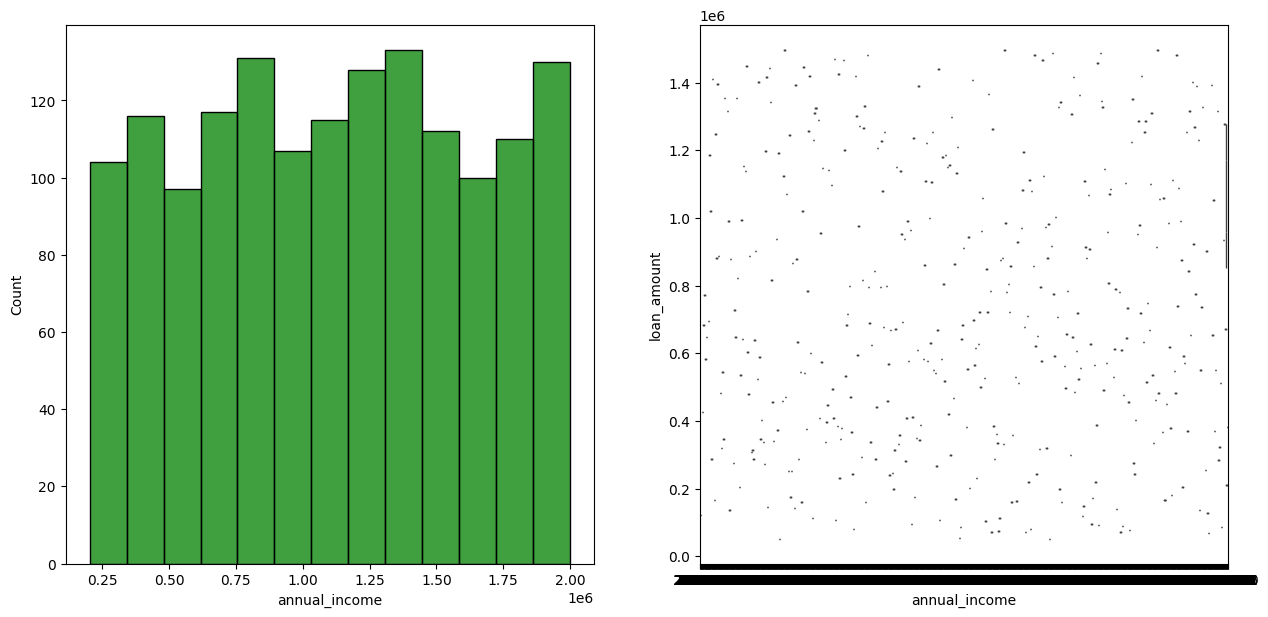

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='annual_income',color='g')
plt.subplot(122)
sns.boxplot(data=df,x='annual_income',y='loan_amount')
plt.show()

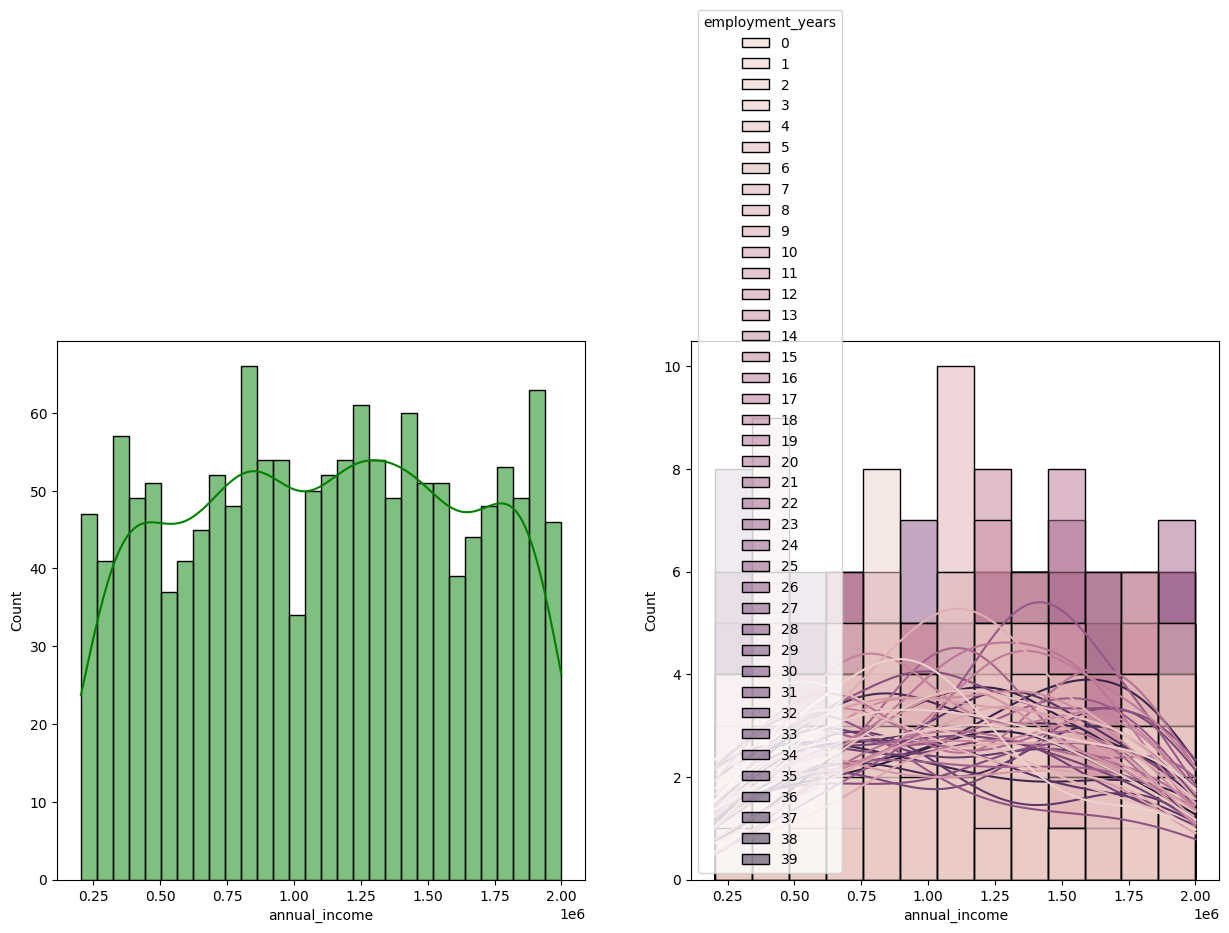

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='annual_income',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='annual_income',kde=True,hue='employment_years')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Grant_Loan'])
X

,age,annual_income,credit_score,loan_amount,employment_years,existing_debt,loan_term_years
0,59,565464,699,1109670,5,633123,13
1,49,813089,481,1000922,31,142003,2
2,35,1536651,504,515590,38,782516,7
3,63,1342953,527,1483284,30,597457,15
4,28,526916,549,1167374,9,260529,11
...,...,...,...,...,...,...,...
1495,61,1904098,749,1231110,23,367968,16
1496,23,1152246,373,1180017,36,222603,8
1497,48,219675,575,1336188,35,791841,13
1498,49,273997,347,483797,35,42438,11


In [16]:
y = df['Grant_Loan']
y = y.replace({'Yes': 1, 'No': 0})
y


0       1
1       1
2       1
3       1
4       1
       ..
1495    0
1496    1
1497    1
1498    1
1499    1
Name: Grant_Loan, Length: 1500, dtype: object

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

train = pd.concat([X_train,y_train],axis=1)
test = pd.concat([X_test,y_test],axis = 1)

In [18]:
train

,age,annual_income,credit_score,loan_amount,employment_years,existing_debt,loan_term_years,Grant_Loan
382,42,887220,492,576249,15,807040,18,1
538,39,1883541,834,1160178,32,999291,16,1
1493,54,864917,682,133791,4,430423,16,0
1112,63,752959,557,1250475,1,842000,18,1
324,55,298818,631,806967,28,866453,1,1
...,...,...,...,...,...,...,...,...
1130,40,263936,382,151894,2,11017,17,1
1294,56,433103,474,1417372,32,736786,18,1
860,54,1875611,390,843567,31,518790,4,1
1459,45,1906032,326,137980,34,738157,8,1


In [20]:
train.to_csv('train.csv')
test.to_csv('test.csv')